## Carregar bibliotecas e banco de dados

In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
filename = "data.jsonl.gz"
path = os.path.abspath(f"./datasets/{filename}")
filename2 = "data-cpcEyear_publishedTO2000BR.gz"
path2 = os.path.abspath(f"./datasets/{filename2}")
print("path: ", path)
print("path: ", path2)

df = pd.read_json(path, lines=True)

path:  c:\Users\dimit\projects\artigo-rp2\analise_patentes\datasets\data.jsonl.gz
path:  c:\Users\dimit\projects\artigo-rp2\analise_patentes\datasets\data-cpcEyear_publishedTO2000BR.gz


In [3]:
display(len(df))
print(df.columns)

50000

Index(['lens_id', 'jurisdiction', 'doc_number', 'kind', 'date_published',
       'doc_key', 'docdb_id', 'lang', 'biblio', 'families', 'legal_status',
       'publication_type', 'abstract'],
      dtype='object')


## Realizar limpeza dos dados

In [4]:
sets_used = ['jurisdiction', 'kind', 
             'date_published', 'docdb_id', 
             'biblio', 'families', 
             'legal_status', 'abstract']

# remoção de NAs
filtered_df = df.dropna(subset=sets_used)

display(filtered_df['biblio'].astype(str))

# filtro por publicações brasileiras
filtered_df = filtered_df[filtered_df['biblio'].astype(str).str.contains('BR')]
filtered_df = filtered_df[filtered_df['jurisdiction'].astype(str).str.contains('BR')]


3        {'publication_reference': {'jurisdiction': 'BR...
4        {'publication_reference': {'jurisdiction': 'BR...
5        {'publication_reference': {'jurisdiction': 'BR...
6        {'publication_reference': {'jurisdiction': 'BR...
7        {'publication_reference': {'jurisdiction': 'BR...
                               ...                        
49994    {'publication_reference': {'jurisdiction': 'BR...
49995    {'publication_reference': {'jurisdiction': 'BR...
49997    {'publication_reference': {'jurisdiction': 'BR...
49998    {'publication_reference': {'jurisdiction': 'BR...
49999    {'publication_reference': {'jurisdiction': 'BR...
Name: biblio, Length: 38630, dtype: object

## Extração de novos campos

### Texto do abstract

In [5]:

# extrai o campo 'text' do dicionário presente em cada linha da coluna 'abstract'
filtered_df['abstract_text'] = filtered_df['abstract'].apply(lambda x: x[0]['text'] if isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict) and 'text' in x[0] else None)

### Classificações IPCR e CPC

In [6]:
# extrai triplas (symbol, value, position) de classificações IPCR e CPC
def _triples_from_classifications_block(block):
    if not isinstance(block, dict):
        return []
    cls = block.get('classifications') if 'classifications' in block else None
    if not isinstance(cls, list):
        return []
    triples = []
    for c in cls:
        if not isinstance(c, dict):
            continue
        triples.append((c.get('symbol'), c.get('classification_value'), c.get('classification_symbol_position')))
    return triples

def extract_triples_from_biblio(biblio):
    if not isinstance(biblio, dict):
        return [], []
    ipcr_block = biblio.get('classifications_ipcr') or biblio.get('classifications_ipcr', {})
    cpc_block = biblio.get('classifications_cpc') or biblio.get('classifications_cpc', {})
    ipcr_triples = _triples_from_classifications_block(ipcr_block)
    cpc_triples = _triples_from_classifications_block(cpc_block)
    return ipcr_triples, cpc_triples

filtered_df[['ipcr_triples', 'cpc_triples']] = filtered_df['biblio'].apply(lambda b: pd.Series(extract_triples_from_biblio(b)))

filtered_df['all_triples'] = filtered_df.apply(lambda r: (r['ipcr_triples'] or []) + (r['cpc_triples'] or []), axis=1)

### Inventors

In [7]:
def extract_inventors_from_biblio(biblio):
    """Return (detailed_list, names_list) where detailed_list is list of {'residence': ..., 'name': ...} and names_list is list of names."""
    if not isinstance(biblio, dict):
        return [], []
    parties = biblio.get('parties') if 'parties' in biblio else {}
    if not isinstance(parties, dict):
        return [], []
    invs = parties.get('inventors')
    if not isinstance(invs, list):
        return [], []
    detailed = []
    names = []
    for inv in invs:
        if not isinstance(inv, dict):
            continue
        residence = inv.get('residence')
        name = None
        if isinstance(inv.get('extracted_name'), dict):
            name = inv['extracted_name'].get('value')
        if not name:
            name = inv.get('name') or (inv.get('extracted') if isinstance(inv.get('extracted'), str) else None)
        detailed.append({'residence': residence, 'name': name})
        if name:
            names.append(name)
    return detailed, names

filtered_df[['inventors_detailed','inventor_names']] = filtered_df['biblio'].apply(lambda b: pd.Series(extract_inventors_from_biblio(b)))

# --- new: extract invention title and owners ---
def extract_invention_title(biblio):
    """Return the invention title text (first entry) or None"""
    if not isinstance(biblio, dict):
        return None
    it = biblio.get('invention_title')
    if isinstance(it, list) and len(it) > 0:
        first = it[0]
        if isinstance(first, dict):
            return first.get('text') or first.get('value')
        if isinstance(first, str):
            return first
    return None

filtered_df['invention_title_text'] = filtered_df['biblio'].apply(extract_invention_title)

### Patentes cited by

In [8]:
# Extrai patent_count e lens_ids de filtered_df['biblio']
def extract_patents_info(biblio):
    if not isinstance(biblio, dict):
        return 0, []
    cb = biblio.get('cited_by') or {}
    # padrão esperado: {'patents': [...], 'patent_count': N}
    patents = []
    count = 0
    if isinstance(cb, dict):
        if isinstance(cb.get('patents'), list):
            patents = cb.get('patents')
            count = cb.get('patent_count', len(patents))
        elif isinstance(cb.get('patents'), dict):
            patents = list(cb.get('patents').values())
            count = cb.get('patent_count', len(patents))
        else:
            # talvez cb itself seja a lista de patents ou um mapeamento
            if isinstance(cb.get('patents'), list):
                patents = cb.get('patents')
                count = len(patents)
            else:
                # fallback: count only
                count = cb.get('patent_count', 0)
                patents = []
    elif isinstance(cb, list):
        patents = cb
        count = len(patents)
    else:
        count = 0

    lens_ids = []
    for p in patents:
        if not isinstance(p, dict):
            continue
        # lens_id frequentemente na raiz do registro de patente
        lid = p.get('lens_id') or (p.get('document_id', {}) or {}).get('lens_id')
        # às vezes lens_id pode estar como 'lens id' ou similar - tratar básico
        if not lid:
            lid = p.get('lens id') or p.get('lens')
        if lid:
            lens_ids.append(lid)
    return count, lens_ids

# aplicar ao DataFrame
filtered_df[['patent_count','patent_lens_ids']] = filtered_df['biblio'].apply(lambda b: pd.Series(extract_patents_info(b)))

filtered_df = filtered_df.reset_index(drop=True)

# visualização rápida
filtered_df[filtered_df['patent_count'] > 6][['docdb_id','patent_count','patent_lens_ids']].head()

,docdb_id,patent_count,patent_lens_ids
2248,410568163,7,"[009-112-160-556-731, 126-749-947-864-359, 022..."
10065,279427515,10,"[088-469-350-389-118, 066-068-825-399-403, 083..."
10067,451354979,8,"[030-613-929-122-614, 054-771-746-098-337, 108..."
10082,522818179,26,"[064-856-910-155-483, 116-462-036-170-646, 064..."
14389,449883948,15,"[043-472-868-631-815, 090-067-059-203-736, 061..."


### Informações de status e expiração

In [9]:
import ast

# extrai patent_status e application_expiry_date da coluna 'legal_status'
def extract_legal_status_info(legal_status):
    if legal_status is None:
        return None, None
    # já é dict
    if isinstance(legal_status, dict):
        return legal_status.get('patent_status'), legal_status.get('application_expiry_date')
    # se for string, tentar avaliar
    if isinstance(legal_status, str):
        try:
            obj = ast.literal_eval(legal_status)
            if isinstance(obj, dict):
                return obj.get('patent_status'), obj.get('application_expiry_date')
        except Exception:
            # não foi possível interpretar
            return None, None
    return None, None

# aplicar e criar novas colunas
filtered_df[['patent_status','application_expiry_date']] = filtered_df['legal_status'].apply(lambda x: pd.Series(extract_legal_status_info(x)))

# quick check
filtered_df[['docdb_id','patent_status','application_expiry_date']].head()

,docdb_id,patent_status,application_expiry_date
0,558602417,PENDING,None
1,383346957,DISCONTINUED,2013-09-03
2,383323608,DISCONTINUED,2011-07-26
3,569902860,ACTIVE,None
4,586397134,DISCONTINUED,2024-09-10


### Análise IPCR

In [10]:
filtered_df.columns

display(filtered_df[['ipcr_triples', 'invention_title_text']])

,ipcr_triples,invention_title_text
0,"[(B01D17/00, I, F), (B01D21/24, I, L), (C02F1/...",Dispositivo de sedimentação
1,"[(E02B9/00, I, F)]",canal com turbinas acoplados nos geradores par...
2,"[(E04H17/06, I, None)]","Mola tensionadora de fio de arame farpado, de ..."
3,"[(E06B11/02, I, F), (E05F15/60, I, L), (F16H57...",Sistema contentor de lubrificantes para automa...
4,"[(F03B13/00, I, F), (E02B9/00, I, L), (F03B15/...",MÉTODO DE GERAÇÃO DE ENERGIA ELÉTRICA E SISTEM...
...,...,...
38625,"[(E04F21/24, I, F), (A43C19/00, I, L)]",DISPOSIÇÃO CONSTRUTIVA APLICADA EM SAPATO COM ...
38626,"[(E21B43/36, I, F), (B01D21/00, I, L)]","MÉTODO E SISTEMA PARA SEPARAÇÃO DE ÁGUA, E, US..."
38627,"[(E05G1/024, I, None)]",Blindagem anti-furo para cofres e caixas forte...
38628,"[(E05C17/20, I, F), (E05F5/00, I, L)]",freio de porta para um automóvel


In [11]:
# ...existing code...
from collections import Counter, defaultdict
import pandas as pd

# containers para full + prefix lengths
counters = {
    'full': Counter(),
    4: Counter(),
    3: Counter(),
    2: Counter(),
    1: Counter()
}
doc_counts = {
    'full': defaultdict(int),
    4: defaultdict(int),
    3: defaultdict(int),
    2: defaultdict(int),
    1: defaultdict(int)
}

for idx, triples in filtered_df['ipcr_triples'].items():
    if not isinstance(triples, list):
        continue
    seen = { 'full': set(), 4: set(), 3: set(), 2: set(), 1: set() }
    for t in triples:
        if isinstance(t, (list, tuple)) and len(t) > 0:
            sym = t[0]
        elif isinstance(t, dict):
            sym = t.get('symbol')
        else:
            sym = None
        if not sym or not isinstance(sym, str):
            continue
        # full
        counters['full'][sym] += 1
        seen['full'].add(sym)
        # prefixes
        for n in (4,3,2,1):
            prefix = sym[:n]
            counters[n][prefix] += 1
            seen[n].add(prefix)
    # incrementar document_count para cada nível
    for k in seen:
        for s in seen[k]:
            doc_counts[k][s] += 1

# função utilitária para criar DataFrame
def make_ipcr_df(counter, doccount, col_name='symbol'):
    df = pd.DataFrame([(s, counter[s], doccount[s]) for s in counter],
                      columns=[col_name, 'occurrences', 'document_count'])
    return df.sort_values(['occurrences', col_name], ascending=[False, True]).reset_index(drop=True)

# DataFrames resultantes
ipcr_full_df = make_ipcr_df(counters['full'], doc_counts['full'], col_name='symbol_full')
ipcr_4_df = make_ipcr_df(counters[4], doc_counts[4], col_name='symbol_4')
ipcr_3_df = make_ipcr_df(counters[3], doc_counts[3], col_name='symbol_3')
ipcr_2_df = make_ipcr_df(counters[2], doc_counts[2], col_name='symbol_2')
ipcr_1_df = make_ipcr_df(counters[1], doc_counts[1], col_name='symbol_1')

# visualizar rapidamente
ipcr_full_df.head(), ipcr_4_df.head(), ipcr_3_df.head(), ipcr_2_df.head(), ipcr_1_df.head()
# ...existing code...
# filepath: c:\Users\dimit\projects\artigo-rp2\dimi\analise-1.ipynb
# ...existing code...
from collections import Counter, defaultdict
import pandas as pd

# containers para full + prefix lengths
counters = {
    'full': Counter(),
    4: Counter(),
    3: Counter(),
    2: Counter(),
    1: Counter()
}
doc_counts = {
    'full': defaultdict(int),
    4: defaultdict(int),
    3: defaultdict(int),
    2: defaultdict(int),
    1: defaultdict(int)
}

for idx, triples in filtered_df['ipcr_triples'].items():
    if not isinstance(triples, list):
        continue
    seen = { 'full': set(), 4: set(), 3: set(), 2: set(), 1: set() }
    for t in triples:
        if isinstance(t, (list, tuple)) and len(t) > 0:
            sym = t[0]
        elif isinstance(t, dict):
            sym = t.get('symbol')
        else:
            sym = None
        if not sym or not isinstance(sym, str):
            continue
        # full
        counters['full'][sym] += 1
        seen['full'].add(sym)
        # prefixes
        for n in (4,3,2,1):
            prefix = sym[:n]
            counters[n][prefix] += 1
            seen[n].add(prefix)
    # incrementar document_count para cada nível
    for k in seen:
        for s in seen[k]:
            doc_counts[k][s] += 1

# função utilitária para criar DataFrame
def make_ipcr_df(counter, doccount, col_name='symbol'):
    df = pd.DataFrame([(s, counter[s], doccount[s]) for s in counter],
                      columns=[col_name, 'occurrences', 'document_count'])
    return df.sort_values(['occurrences', col_name], ascending=[False, True]).reset_index(drop=True)

# DataFrames resultantes
ipcr_full_df = make_ipcr_df(counters['full'], doc_counts['full'], col_name='symbol_full')
ipcr_4_df = make_ipcr_df(counters[4], doc_counts[4], col_name='symbol_4')
ipcr_3_df = make_ipcr_df(counters[3], doc_counts[3], col_name='symbol_3')
ipcr_2_df = make_ipcr_df(counters[2], doc_counts[2], col_name='symbol_2')
ipcr_1_df = make_ipcr_df(counters[1], doc_counts[1], col_name='symbol_1')

# visualizar rapidamente
display(ipcr_full_df.head())
display(ipcr_4_df.head())
display(ipcr_3_df.head())
display(ipcr_2_df.head())
display(ipcr_1_df.head(10))

len(ipcr_full_df), len(ipcr_4_df), len(ipcr_3_df), len(ipcr_2_df), len(ipcr_1_df)

,symbol_full,occurrences,document_count
0,E21B43/12,941,941
1,E21B47/00,892,892
2,E21B41/00,739,739
3,E21B47/12,661,661
4,E21B17/01,644,644


,symbol_4,occurrences,document_count
0,E21B,25707,13175
1,E05B,3837,2215
2,E04B,3737,2631
3,E06B,3414,2403
4,E04H,3226,2663


,symbol_3,occurrences,document_count
0,E21,26433,13581
1,E04,15475,10017
2,E05,8052,4778
3,E03,4597,3621
4,E02,4424,2981


,symbol_2,occurrences,document_count
0,E0,39635,25278
1,E2,26433,13581
2,G0,4526,2598
3,C0,4308,1727
4,B6,3883,2316


,symbol_1,occurrences,document_count
0,E,66069,38630
1,B,9228,4589
2,F,5830,3505
3,C,5113,1929
4,G,4674,2679
5,A,1976,1342
6,H,1747,993
7,D,487,194


(11246, 507, 122, 30, 8)

No bloco abaixo, exploramos os códigos entre as patentes coletadas do Lens, identificamos as que não estão relacionadas ao tema de engenharia civil principalmente e excluimos elas. A E21 é relacionada a mineração, portanto será excluida.

In [12]:
priority = ["E","B","F","C","G","H","A","D","E21","E04"]  

def pick_code(triples, n=1, priority=priority):
    if not triples:
        return None
    codes = [t[0][:n] for t in triples if t and t[0]]
    if not codes:
        return None
    # ordena prioridades: prefixos mais longos primeiro
    ordered = sorted(priority, key=len, reverse=False)
    for p in ordered:
        for c in codes:
            if c.startswith(p):
                return c
    return None

def summarize(df, n, prefix=None, inplace=False):
    
    
    if not inplace:
        df = df.copy()
    df["picked"] = df["ipcr_triples"].apply(lambda x: pick_code(x, n))
    if prefix:
        df = df[df["picked"].str.startswith(prefix, na=False)]
    return df["picked"].value_counts().rename_axis("Code").reset_index(name="Count")

# exemplo
result1 = summarize(filtered_df, n=3, inplace=True)
display(result1)

result2 = summarize(filtered_df, n=4, prefix="E21")
display(result2)

result2 = summarize(filtered_df, n=5, prefix="E21")
display(result2)

filtered_ipcr = filtered_df[filtered_df['picked'] != "E21"].copy()

display(len(filtered_df))
display(len(filtered_ipcr))

,Code,Count
0,E21,13390
1,E04,9678
2,E05,4662
3,E03,3539
4,E02,2820
5,E06,2282
6,E01,2259


,Code,Count
0,E21B,13030
1,E21C,177
2,E21D,133
3,E21F,50


,Code,Count
0,E21B4,5012
1,E21B3,3013
2,E21B1,2974
3,E21B2,1437
4,E21B7,519
5,E21C4,70
6,E21C3,65
7,E21B/,65
8,E21D2,56
9,E21F1,41


38630

25240

## Análise dos dados


### Análise dos IPCs

In [13]:
import dataframe_image as dfi

result1 = summarize(filtered_ipcr, n=3)
display(result1)
styled_df = (result1.style
                 .set_caption(f'Tabela com {n} caracteres')
                 .set_table_styles([
                     {'selector': 'caption', 'props': 'font-size: 16pt; font-weight: bold;'},
                     {'selector': 'th', 'props': 'font-size: 12pt;'},
                     {'selector': 'td', 'props': 'font-size: 12pt;'}
                 ])
                 .hide(axis="index"))
   
dfi.export(styled_df, 'tabela-3-ipcr.png', table_conversion='matplotlib')
result1 = summarize(filtered_ipcr, n=4)
dfi.export(result1.head(5), 'tabela-4-ipcr.png', table_conversion='matplotlib')
result1 = summarize(filtered_ipcr, n=5)
dfi.export(result1.head(5), 'tabela-5-ipcr.png', table_conversion='matplotlib')

,Code,Count
0,E04,9678
1,E05,4662
2,E03,3539
3,E02,2820
4,E06,2282
5,E01,2259


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
# Geração das tabelas
for n in [3, 4, 5]:
    df_result = summarize(filtered_ipcr, n).head(5)

    num_rows = len(df_result)
    num_cols = len(df_result.columns)
    
    # Reduz o tamanho da figura para minimizar o espaço
    fig_height = 0.2 + num_rows * 0.3
    fig_width = 1.0 + num_cols * 1.2
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    
    # Reduz o pad do título para aproximá-lo do conteúdo
    ax.set_title(f'{n} caracteres', fontsize=16, fontweight='bold', pad=2)

    table = ax.table(cellText=df_result.values,
                     colLabels=df_result.columns,
                     loc='center',
                     cellLoc='center')
    
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.0, 1.2)

    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0.5)
        cell.set_edgecolor("black")
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor("#e0e0e0")

    # Garante que o layout seja o mais compacto possível
    plt.tight_layout(pad=0.1)
    
    plt.savefig(f'./graficos/tabela-{n}-final.png', bbox_inches='tight', dpi=300)
    plt.close(fig)

In [15]:
from PIL import Image

def concatenate_images_horizontally_with_spacing(image_paths, spacing=20):
    """
    Carrega as imagens, ajusta suas alturas e as concatena horizontalmente com espaçamento.
    """
    images = [Image.open(path) for path in image_paths]
    
    # Encontra a altura máxima para redimensionamento.
    max_height = max(img.height for img in images)
    
    # Redimensiona cada imagem para a altura máxima, mantendo a proporção da largura.
    resized_images = []
    for img in images:
        if img.height != max_height:
            new_width = int(img.width * (max_height / img.height))
            resized_images.append(img.resize((new_width, max_height), Image.LANCZOS))
        else:
            resized_images.append(img)
            
    # Calcula a largura total da nova imagem, incluindo os espaçamentos.
    total_width = sum(img.width for img in resized_images) + (len(resized_images) - 1) * spacing
    
    # Cria uma nova imagem em branco com a largura total e a altura máxima.
    new_image = Image.new('RGB', (total_width, max_height), 'white') # Cor de fundo branca
    
    # Cola as imagens redimensionadas na nova imagem, adicionando espaçamento.
    x_offset = 0
    for img in resized_images:
        new_image.paste(img, (x_offset, 0))
        x_offset += img.width + spacing
        
    return new_image

# Caminhos das imagens.
# Certifique-se de que os nomes dos arquivos estão corretos e na ordem desejada.
image_files = ['graficos/tabela-3-final.png', 'graficos/tabela-4-final.png', 'graficos/tabela-5-final.png']

# Define o espaçamento desejado em pixels.
spacing_between_images = 50 # Você pode ajustar este valor

# Concatena as imagens horizontalmente com espaçamento.
concatenated_image = concatenate_images_horizontally_with_spacing(image_files, spacing=spacing_between_images)

# Salva a imagem combinada.
output_path = './graficos/tabelas_lado_a_lado_com_espacamento.png'
concatenated_image.save(output_path)

print(f"Imagem combinada salva em: {output_path}")

Imagem combinada salva em: ./graficos/tabelas_lado_a_lado_com_espacamento.png


### Tendência temporal dos IPCs

In [16]:
filtered_ipcr.head(1).to_csv("teste.csv")

tmp = filtered_ipcr.copy()
tmp['date_published'] = pd.to_datetime(tmp['date_published'])

# Aplica a função pick_code para extrair o código mais importante (n=4)
tmp['ipcr_code'] = tmp['ipcr_triples'].apply(lambda x: pick_code(x, n=3))

# Remove linhas onde pick_code retornou None
tmp.dropna(subset=['ipcr_code'], inplace=True)

# Define a data como índice
tmp = tmp.set_index('date_published')

# Calcula a contagem de códigos por ano
temporal_counts = tmp.groupby('ipcr_code').resample('YE').size().rename('count').reset_index()

top_5_per_year = temporal_counts.sort_values(['date_published', 'count'], ascending=[True, False]) \
                                .groupby('date_published').head(5)

pivoted_data = top_5_per_year.pivot_table(index='date_published', columns='ipcr_code', values='count')

plt.figure(figsize=(12, 7))
pivoted_data.plot(ax=plt.gca(), marker='o', linewidth=2)
plt.title('Tendência Temporal dos 5 Códigos IPCR Mais Frequentes (por Ano)', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Contagem de Patentes', fontsize=12)
plt.grid(True)
plt.legend(title='Código IPCR', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize='12')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('./graficos/analise_temporal_top_5.png')
plt.close()

C:\Users\dimit\AppData\Local\Temp\ipykernel_6004\871056704.py:16: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temporal_counts = tmp.groupby('ipcr_code').resample('YE').size().rename('count').reset_index()


date_published
2000    1166
2001    1084
2002     899
2003     764
2004     958
2005     907
2006     800
2007     654
2008     768
2009     603
2010     652
2011     805
2012     394
2013     826
2014     526
2015     901
2016    1275
2017    1807
2018    1530
2019    1487
2020    1560
2021    1658
2022    1684
2023    1044
Name: date_published, dtype: int64

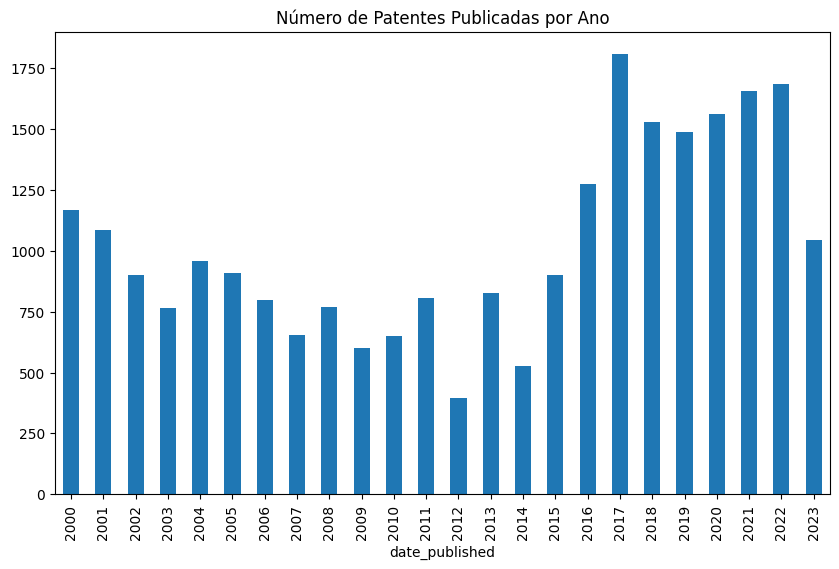

In [17]:
filtered_ipcr['date_published'] = pd.to_datetime(filtered_ipcr['date_published'])

filtered_ipcr = filtered_ipcr[~filtered_ipcr['date_published'].dt.year.isin([1999, 2024])]

filtered_ipcr['date_published'].groupby(filtered_ipcr['date_published'].dt.year).count().plot(kind='bar', figsize=(10,6), title='Número de Patentes Publicadas por Ano')

filtered_ipcr['date_published'].groupby(filtered_ipcr['date_published'].dt.year).count()


In [18]:
# ...existing code...
# Otimizado usando ferramentas do pandas
patents_count_higher_than_one = filtered_ipcr[filtered_ipcr['patent_count'] > 1]

# Explode as listas de patent_lens_ids para criar uma linha por patente citada
citations_expanded = patents_count_higher_than_one[['lens_id', 'patent_lens_ids']].explode('patent_lens_ids')

# Agrupa por patente citada e coleta todas as patentes que citam
citations_grouped = citations_expanded.groupby('patent_lens_ids')['lens_id'].apply(list).reset_index()
citations_grouped.columns = ['patente_citada', 'patentes_citando']

display(citations_grouped.head(10))
# ...existing code...

,patente_citada,patentes_citando
0,000-210-341-398-690,[153-959-374-480-167]
1,000-499-693-443-096,[126-785-046-657-254]
2,000-894-423-923-866,"[033-272-027-666-037, 138-248-579-260-702]"
3,000-945-780-713-098,[121-922-597-198-564]
4,001-134-370-341-33X,[001-983-862-936-782]
5,001-334-427-927-902,[043-623-627-409-370]
6,001-603-047-412-301,[023-086-414-330-945]
7,001-786-449-900-150,[149-059-804-771-40X]
8,001-800-560-262-722,[042-071-023-644-215]
9,001-863-517-333-343,[126-785-046-657-254]


In [19]:
import ast

def extract_family_count(families):
    """
    Extrai o número de jurisdições únicas da família de patentes.
    """
    if families is None:
        return 0
    
    try:
        # Se for string, converte para dict
        if isinstance(families, str):
            families_dict = ast.literal_eval(families)
        else:
            families_dict = families
        
        # Usa extended_family se disponível, senão simple_family
        family_data = families_dict.get('extended_family') or families_dict.get('simple_family')
        
        if not family_data or 'members' not in family_data:
            return 0
        
        # Extrai jurisdições únicas
        jurisdictions = set()
        for member in family_data['members']:
            if isinstance(member, dict) and 'document_id' in member:
                jurisdiction = member['document_id'].get('jurisdiction')
                if jurisdiction:
                    jurisdictions.add(jurisdiction)
        
        return len(jurisdictions)
    
    except Exception:
        return 0

# Adiciona a coluna family_count
filtered_ipcr['family_count'] = filtered_ipcr['families'].apply(extract_family_count)

# Visualiza alguns resultados
print("\nTop 10 patentes com maior family_count:")
filtered_ipcr.nlargest(10, 'family_count')[['lens_id', 'family_count', 'invention_title_text']]


Top 10 patentes com maior family_count:


,lens_id,family_count,invention_title_text
11954,154-177-797-200-817,48,método e sistema para resfriamento sustentável...
30029,187-118-008-405-754,46,Liberação de painéis de vidraça
28472,056-031-588-892-429,45,Método para tratamento de água em um lago flut...
38598,071-235-329-103-753,45,Método para tratamento de água em um lago flut...
15127,187-775-638-575-213,44,fechadura de cilindro de disco basculante e co...
3931,119-815-173-747-237,41,combinação de chave e fechadura de cilindro de...
8315,068-977-237-398-675,41,combinação de chave e fechadura de cilindro de...
9787,180-051-027-439-636,41,"Construção de telhado/teto, composta, duplamen..."
7611,103-005-883-727-278,40,Local de apresentação urbana para fornecer ent...
35274,093-224-482-679-374,40,Método de construção para criar uma lagoa de n...


In [20]:
import ast

def extract_claims_count(biblio):
    """
    Extrai o número de claims (reivindicações de prioridade) da patente.
    """
    if biblio is None:
        return 0
    
    try:
        # Se for string, converte para dict
        if isinstance(biblio, str):
            biblio_dict = ast.literal_eval(biblio)
        else:
            biblio_dict = biblio
        
        # Acessa priority_claims -> claims
        priority_claims = biblio_dict.get('priority_claims', {})
        claims = priority_claims.get('claims', [])
        
        # Retorna o número de claims
        return len(claims) if isinstance(claims, list) else 0
    
    except Exception:
        return 0

# Adiciona a coluna claims_count
filtered_ipcr['claims_count'] = filtered_ipcr['biblio'].apply(extract_claims_count)

print("\nExemplos:")
filtered_ipcr[['lens_id', 'claims_count', 'invention_title_text']].nlargest(10, 'claims_count')


Exemplos:


,lens_id,claims_count,invention_title_text
5840,053-827-835-702-317,12,unidades de parede de inundação retrátil e de ...
16143,072-835-844-504-477,12,UNIDADE DE PAREDE DE INUNDAÇÃO RETRÁTIL E DE E...
2464,050-947-292-558-300,11,?vidro arquitetônico termicamente reforçado e ...
8220,046-642-643-895-746,10,unidades de construção dobráveis
3784,104-049-632-648-939,9,"âncora de parafuso, conjunto de âncora de para..."
36737,116-188-275-032-25X,9,"conjunto de condução de âncora de parafuso, co..."
6360,110-006-514-920-441,8,Suporte de via
14571,165-479-377-903-80X,8,Viga para via de locomoção para veìculo guiado...
22697,012-244-877-331-84X,8,Montagem de âncora e balaustrada para ancorar ...
35467,018-642-001-470-425,8,Suporte para veìculo de alta velocidade sobre ...


In [22]:
filtered_ipcr.iloc[123].to_csv("test15.csv")
filtered_ipcr.to_csv('./datasets/database-filtrado.csv.zip', index=False, compression='zip')